In [18]:
import os
while not os.path.isdir('.git'):
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"

import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

import glob
import re

project = "temporal-interference-1"

# Subthreshold electric field strength

In [19]:
subthreshold = []

for file in glob.glob(f"output/{project}/variable-time-ef/*_*_*.csv"):
    pattern = re.compile(r"([^/]+)_([^/]+)_([^/]+)\.csv$")
    phi, psi, carrier = pattern.search(file).groups()

    data = pd.read_csv(file)
    data["Phi"] = int(phi)
    data["Psi"] = int(psi)
    data["Carrier"] = int(carrier)

    subthreshold.append(data)

subthreshold = pd.concat(subthreshold, ignore_index = True)

In [20]:
carriers = [1000, 2000, 5000, 9000]
colors = {
    1000: "tab:blue",
    2000: "tab:orange",
    5000: "tab:green",
    9000: "tab:red"
}

phi = 90
psi = 90

In [21]:
subthreshold

,Psi,Phi,Carrier,Beat,SubthresholdAmplitude,SubthresholdAmplitudeStep,LastAP
0,90,90,2000,0.0,794.433594,0.244141,False
1,90,90,2000,0.5,233.154297,0.122070,False
2,90,90,2000,1.0,231.933594,0.244141,False
3,90,90,2000,2.0,231.201172,0.122070,False
4,90,90,2000,3.0,230.834961,0.061035,False
...,...,...,...,...,...,...,...
227,90,90,9000,100.0,828.170776,0.007629,False
228,90,90,9000,110.0,830.444336,0.061035,False
229,90,90,9000,120.0,832.763672,0.122070,False
230,90,90,9000,130.0,834.350586,0.061035,False


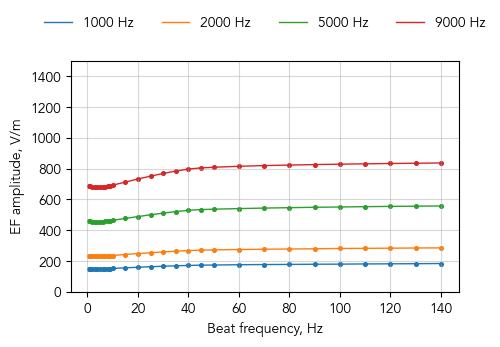

In [22]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (5, 3))

for carrier in carriers:
    dt = subthreshold[
        (subthreshold.Phi == phi) &
        (subthreshold.Psi == psi) &
        (subthreshold.Carrier == carrier) &
        (subthreshold.Beat >= 0.05)
    ]

    color = colors[carrier]

    ax.plot(dt.Beat, dt.SubthresholdAmplitude, linewidth = 1, label = f"{carrier} Hz", color = color)
    ax.scatter(dt.Beat, dt.SubthresholdAmplitude, s = 7, color = color)

ax.set_xlabel("Beat frequency, Hz")
ax.set_ylabel("EF amplitude, V/m")
# ax.set_xscale("log")
ax.grid(alpha = 0.5)
ax.set_ylim(0, 1500)
ax.legend(loc = "upper center", ncol = 4, frameon = False, bbox_to_anchor = (0.5, 1.25))

plt.show()

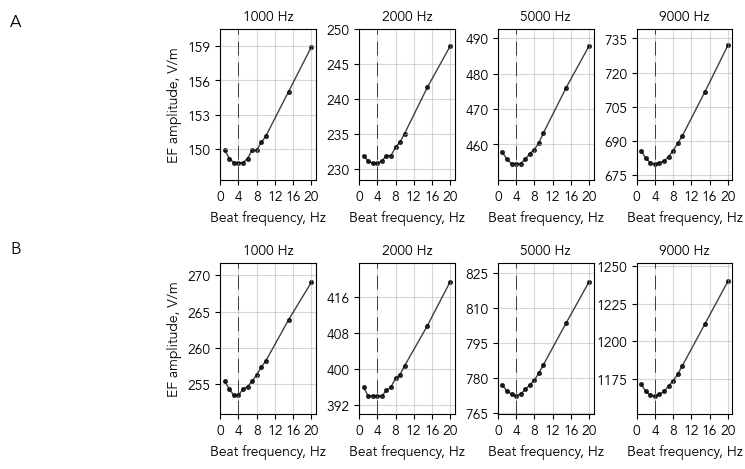

In [17]:
fig = plt.figure(figsize = (8.4, 5))

outer_gs = gridspec.GridSpec(3, 1, height_ratios = [1, 0.25, 1])

# --- A panel ---
inner_gs = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec = outer_gs[0], wspace = 0.45)
ax_c1 = fig.add_subplot(inner_gs[1])
ax_c2 = fig.add_subplot(inner_gs[2])
ax_c3 = fig.add_subplot(inner_gs[3])
ax_c4 = fig.add_subplot(inner_gs[4])

axs = [ax_c1, ax_c2, ax_c3, ax_c4]

for i, carrier in enumerate(carriers):
    dt = subthreshold[
        (subthreshold.Phi == 90) &
        (subthreshold.Psi == 90) &
        (subthreshold.Carrier == carrier) &
        (subthreshold.Beat > 0.5) &
        (subthreshold.Beat <= 20)
        ].copy()

    color = "black"

    min_amplitude_at = round(dt[dt.SubthresholdAmplitude == dt.SubthresholdAmplitude.min()].Beat.mean())

    ymin = dt.SubthresholdAmplitude.min()
    ymin = ymin - 0.01 * ymin

    ymax = dt.SubthresholdAmplitude.max()
    ymax = ymax + 0.01 * ymax

    axs[i].axvline(x = min_amplitude_at, color = "black", linestyle = (0, (20, 10)), linewidth = 0.5)
    axs[i].plot(dt.Beat, dt.SubthresholdAmplitude, linewidth = 1, label = f"{carrier} Hz", color = color, alpha = 0.75)
    axs[i].scatter(dt.Beat, dt.SubthresholdAmplitude, s = 7, color = color, alpha = 0.75)
    axs[i].set_ylim(ymin, ymax)
    axs[i].set_xlim(0, 21)
    axs[i].set_xticks([0, 4, 8, 12, 16, 20])

    axs[i].grid(alpha = 0.5)
    axs[i].yaxis.set_major_locator(MaxNLocator(nbins = 5))

    axs[i].set_title(f"{carrier} Hz", fontsize = 10)

for ax in axs:
    ax.set_xlabel("Beat frequency, Hz")

axs[0].set_ylabel("EF amplitude, V/m")

# --- A panel ---
inner_gs = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec = outer_gs[2], wspace = 0.45)
ax_c1 = fig.add_subplot(inner_gs[1])
ax_c2 = fig.add_subplot(inner_gs[2])
ax_c3 = fig.add_subplot(inner_gs[3])
ax_c4 = fig.add_subplot(inner_gs[4])

axs = [ax_c1, ax_c2, ax_c3, ax_c4]

carriers = [1000, 2000, 5000, 9000]
colors = {
    1000: "tab:blue",
    2000: "tab:orange",
    5000: "tab:green",
    9000: "tab:red"
}

for i, carrier in enumerate(carriers):
    dt = subthreshold[
        (subthreshold.Phi == 0) &
        (subthreshold.Psi == 180) &
        (subthreshold.Carrier == carrier) &
        (subthreshold.Beat > 0.5) &
        (subthreshold.Beat <= 20)
        ].copy()

    color = "black"
    min_amplitude_at = round(dt[dt.SubthresholdAmplitude == dt.SubthresholdAmplitude.min()].Beat.mean())

    ymin = dt.SubthresholdAmplitude.min()
    ymin = ymin - 0.01 * ymin

    ymax = dt.SubthresholdAmplitude.max()
    ymax = ymax + 0.01 * ymax

    axs[i].axvline(x = min_amplitude_at, color = "black", linestyle = (0, (20, 10)), linewidth = 0.5)
    axs[i].plot(dt.Beat, dt.SubthresholdAmplitude, linewidth = 1, label = f"{carrier} Hz", color = color, alpha = 0.75)
    axs[i].scatter(dt.Beat, dt.SubthresholdAmplitude, s = 7, color = color, alpha = 0.75)
    axs[i].set_ylim(ymin, ymax)
    axs[i].set_xlim(0, 21)
    axs[i].set_xticks([0, 4, 8, 12, 16, 20])

    axs[i].grid(alpha = 0.5)
    axs[i].yaxis.set_major_locator(MaxNLocator(nbins = 5))

    axs[i].set_title(f"{carrier} Hz", fontsize = 10)

for ax in axs:
    ax.set_xlabel("Beat frequency, Hz")

axs[0].set_ylabel("EF amplitude, V/m")

fig.text(0.04, 0.885, "A", fontsize = 12)
fig.text(0.04, 0.43, "B", fontsize = 12)

plt.savefig("supplementary_results_1.png", dpi = 2500, bbox_inches = "tight")